In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("Game_dataset.csv")
df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,TotalPlayTime,HighEngagementFlag,AgeGroup
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28,Apple Pay,19-03-2025,115.47,False,36-50
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18,Debit Card,08-06-2025,213.29,False,<18
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30,Apple Pay,02-06-2025,79.83,False,18-25
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9,Debit Card,01-04-2025,234.72,False,26-35
4,aa7eec14-4846-47b9-b879-9c98038cda04,37,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15,Paypal,05-05-2025,152.30,False,36-50


In [8]:
df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'], errors='coerce')


/tmp/ipykernel_232/1230889082.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'], errors='coerce')


# Retention & Churn Metrics

***Churn Flag*** –Churned players are those players who haven’t played recently or haven’t made a purchase in X days.

In [12]:
analysis_date = df['LastPurchaseDate'].max()

In [13]:
# Defining churn threshold (e.g., no session in last 30 days OR no purchase in 60 days)
df['ChurnFlag'] = np.where(
    (df['LastPurchaseDate'] < analysis_date - pd.Timedelta(days=60)) |
    (df['TotalPlayTime'] < 30),  # optional threshold for low engagement
    True, False
)

In [14]:
retention_rate = 100 * (1 - df['ChurnFlag'].mean())
print(f"Player Retention Rate: {retention_rate:.2f}%")

Player Retention Rate: 30.77%


**Analyze Retention by Key Segments**

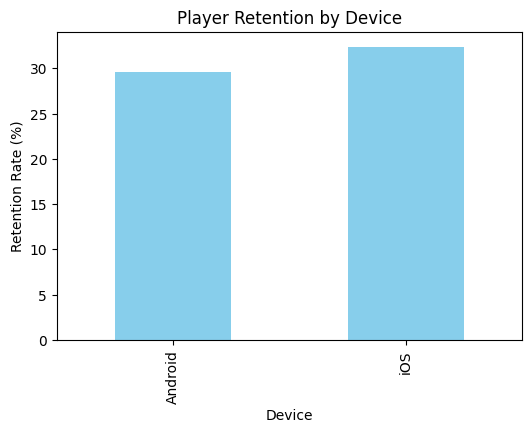

In [15]:
# Retention by Device
device_retention = df.groupby('Device')['ChurnFlag'].apply(lambda x: 100*(1-x.mean()))
device_retention.plot(kind='bar', figsize=(6,4), color='skyblue')
plt.title('Player Retention by Device')
plt.ylabel('Retention Rate (%)')
plt.show()

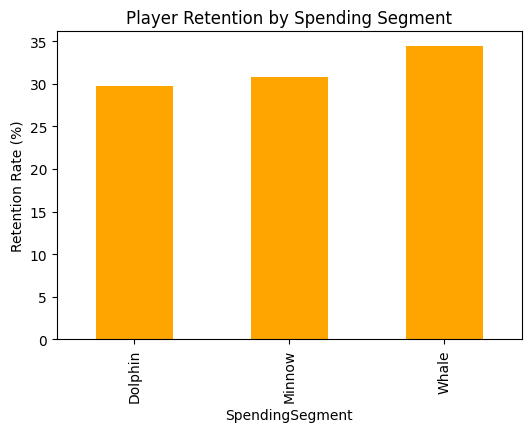

In [16]:
# Retention by Spending Segment
segment_retention = df.groupby('SpendingSegment')['ChurnFlag'].apply(lambda x: 100*(1-x.mean()))
segment_retention.plot(kind='bar', figsize=(6,4), color='orange')
plt.title('Player Retention by Spending Segment')
plt.ylabel('Retention Rate (%)')
plt.show()

In [21]:
segment_retention

,ChurnFlag
SpendingSegment,
Dolphin,29.736842
Minnow,30.846422
Whale,34.426230


***Engagement Metrics vs Retention***

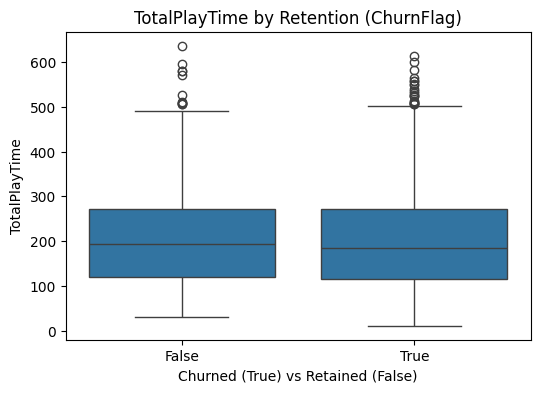

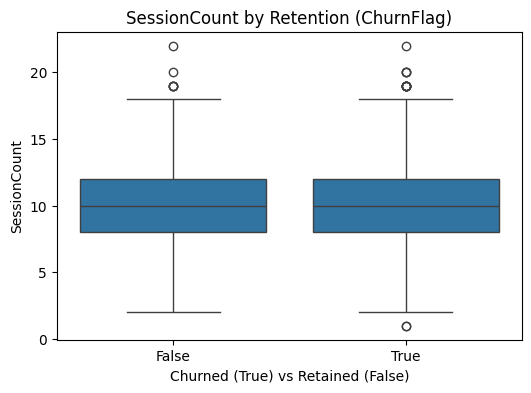

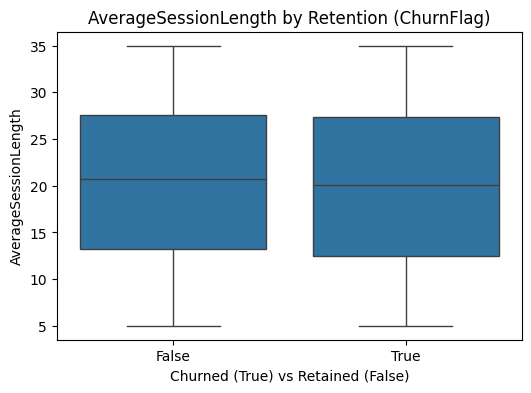

In [17]:
engagement_cols = ['TotalPlayTime','SessionCount','AverageSessionLength']

for col in engagement_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='ChurnFlag', y=col, data=df)
    plt.title(f'{col} by Retention (ChurnFlag)')
    plt.xlabel('Churned (True) vs Retained (False)')
    plt.show()

***Monetization vs Retention***

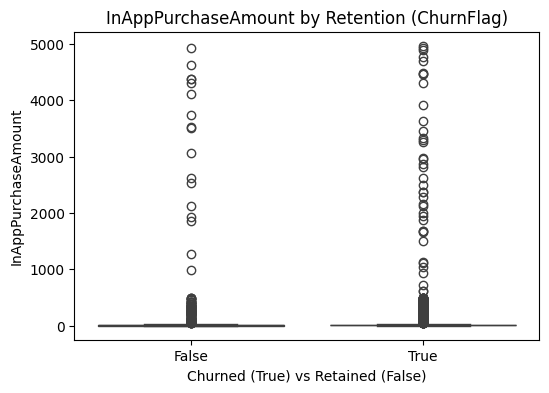

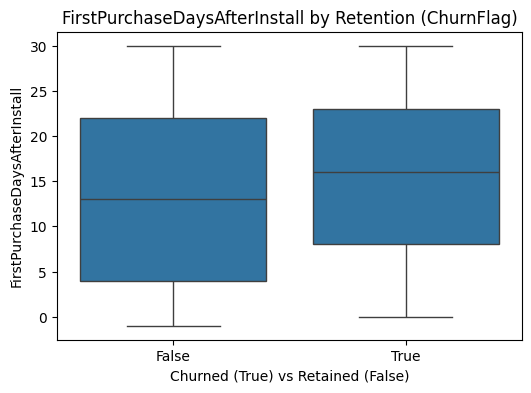

In [18]:
monetization_cols = ['InAppPurchaseAmount','FirstPurchaseDaysAfterInstall']

for col in monetization_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='ChurnFlag', y=col, data=df)
    plt.title(f'{col} by Retention (ChurnFlag)')
    plt.xlabel('Churned (True) vs Retained (False)')
    plt.show()

***Retention by Cohort***

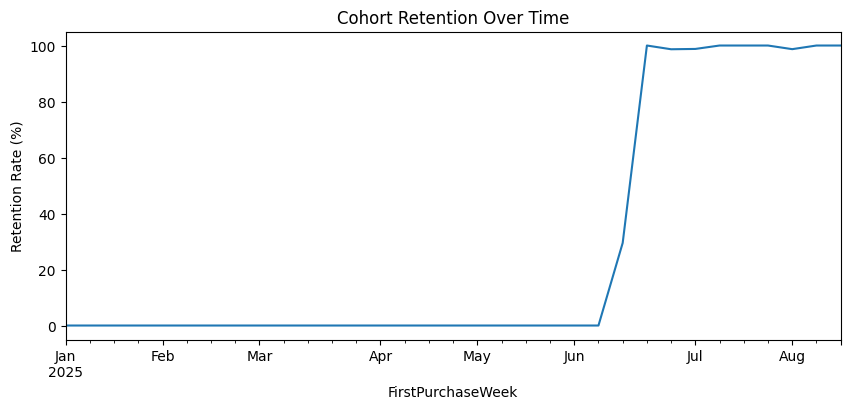

In [19]:
df['FirstPurchaseWeek'] = pd.to_datetime(df['LastPurchaseDate']).dt.to_period('W')
cohort_retention = df.groupby('FirstPurchaseWeek')['ChurnFlag'].apply(lambda x: 100*(1-x.mean()))
cohort_retention.plot(figsize=(10,4))
plt.title('Cohort Retention Over Time')
plt.ylabel('Retention Rate (%)')
plt.show()

# ***Insights :***

1. **Overall Retention :** Player retention rate is ~30.77% → most players are churning.

2. **Retention by Device :** Android retention ~70.4%, iOS ~67.6% → iOS slightly lower.

3. **Retention by Spending Segment :** Whales have highest churn (34.4%), while Dolphins and Minnows are lower.

4. **Retention by Cohort (FirstPurchaseWeek):** Early cohorts have near 0% churn, but later cohorts show spikes in churn (~100%).

5. **Engagement vs Churn :** Players with higher TotalPlayTime, more sessions, or longer AverageSessionLength are less likely to churn.

6. **Monetization vs Churn :** Early spenders and whales tend to stay longer, while non-paying users are more likely to churn.

**Suggestion:**
1. Focus on improving onboarding and early engagement to increase retention in the first few weeks. For example: tutorial rewards, starter packs, or push notifications.

2. Launch iOS-specific engagement campaigns or device-optimized in-game events to reduce churn.

3. Introduce VIP retention strategies like personalized offers, exclusive rewards, or loyalty programs to retain high-value players.

4. Implement early intervention campaigns for new players: reminders, starter packs, limited-time events in the first 2–3 weeks.

5. Encourage consistent gameplay by adding daily quests, streak rewards, or social features to increase engagement.

6. Incentivize early purchases with starter packs, discounted bundles, or first-purchase rewards to convert players faster and reduce early churn.


# **Overall Recommendation :**

1. Focus on early engagement (first 2–3 weeks) and high-value players (Whales, iOS users).

2. Use cohort-based monitoring to track retention improvements.

3. Combine engagement and monetization insights to design campaigns that increase both revenue and retention.